In [1]:
import os

dataset_path = "/kaggle/input/datasets/abhinaya4678/traffic-sign"

print(os.listdir(dataset_path))

['db_lisa_tiny']


In [2]:
BASE_PATH = "/kaggle/input/datasets/abhinaya4678/traffic-sign"

INPUT_DIR = BASE_PATH
CSV_PATH = f"{BASE_PATH}/annotations.csv"

**Load Dataset**

In [3]:
import os

dataset_path = "/kaggle/input/datasets/abhinaya4678/traffic-sign"

image_extensions = ('.png', '.jpg', '.jpeg')

total_images = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            total_images += 1

print("📂 Total Images in Dataset:", total_images)

📂 Total Images in Dataset: 901


In [4]:
import pandas as pd

csv_path = "/kaggle/input/datasets/abhinaya4678/traffic-sign/db_lisa_tiny/annotations.csv"
df = pd.read_csv(csv_path)
print(df.columns)
df.head()

Index(['filename', 'x1', 'y1', 'x2', 'y2', 'class'], dtype='object')


,filename,x1,y1,x2,y2,class
0,sample_001.png,190,40,211,63,stop
1,sample_002.png,4,246,43,283,stop
2,sample_003.png,389,286,418,314,stop
3,sample_004.png,307,243,315,251,stop
4,sample_005.png,377,249,398,270,stop


In [5]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class LISADataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        
        self.classes = sorted(self.df['class'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img_path = os.path.join(self.image_dir, row['filename'])
        image = Image.open(img_path).convert("RGB")
        
        # 🔥 Crop using bounding box
        x1, y1, x2, y2 = row['x1'], row['y1'], row['x2'], row['y2']
        image = image.crop((x1, y1, x2, y2))
        
        label = self.class_to_idx[row['class']]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

**Total image count**

In [6]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

# Paths
csv_path = "/kaggle/input/datasets/abhinaya4678/traffic-sign/db_lisa_tiny/annotations.csv"
image_dir = "/kaggle/input/datasets/abhinaya4678/traffic-sign/db_lisa_tiny"
output_dir = "/kaggle/working/preprocessed_dataset"

os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(csv_path)

print("Total images:", len(df))

Total images: 900


**Data Preprocessing**

In [7]:
for _, row in tqdm(df.iterrows(), total=len(df)):
    
    filename = row['filename']
    label = row['class']
    
    img_path = os.path.join(image_dir, filename)
    
    # Open image
    image = Image.open(img_path).convert("RGB")
    
    # Crop using bounding box
    x1, y1, x2, y2 = row['x1'], row['y1'], row['x2'], row['y2']
    image = image.crop((x1, y1, x2, y2))
    
    # Resize
    image = image.resize((224,224))
    
    # Create class folder
    class_folder = os.path.join(output_dir, label)
    os.makedirs(class_folder, exist_ok=True)
    
    # Save image
    save_path = os.path.join(class_folder, filename)
    image.save(save_path)

print("Preprocessing Completed ✅")

100%|██████████| 900/900 [00:27<00:00, 32.14it/s]

Preprocessing Completed ✅


In [8]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

In [9]:
source_dir = "/kaggle/working/preprocessed_dataset"
split_dir = "/kaggle/working/dataset_split"

train_dir = os.path.join(split_dir, "train")
test_dir  = os.path.join(split_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

**Split dataset into train and test**

In [10]:
for class_name in os.listdir(source_dir):
    
    class_path = os.path.join(source_dir, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    images = os.listdir(class_path)
    
    train_imgs, test_imgs = train_test_split(
        images,
        test_size=0.2,
        random_state=42
    )
    
    # Create class folders
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)
    
    # Copy train images
    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_dir, class_name, img)
        )
    
    # Copy test images
    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(test_dir, class_name, img)
        )

print("80:20 Split Completed ✅")

80:20 Split Completed ✅


In [11]:
print("Train Classes:", os.listdir(train_dir))
print("Test Classes :", os.listdir(test_dir))

Train Classes: ['yieldAhead', 'speedLimit25', 'pedestrianCrossing', 'yield', 'keepRight', 'signalAhead', 'stop', 'merge', 'speedLimit35']
Test Classes : ['yieldAhead', 'speedLimit25', 'pedestrianCrossing', 'yield', 'keepRight', 'signalAhead', 'stop', 'merge', 'speedLimit35']


**TRAIN DATASET COUNT**

In [12]:
import os

train_dir = "/kaggle/working/dataset_split/train"
test_dir  = "/kaggle/working/dataset_split/test"

print("📊 TRAIN DATASET COUNT")
print("-" * 40)

total_train = 0

for class_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, class_name)
    
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        total_train += count
        print(f"{class_name}: {count}")

print("-" * 40)
print("Total Train Images:", total_train)


print("\n📊 TEST DATASET COUNT")
print("-" * 40)

total_test = 0

for class_name in sorted(os.listdir(test_dir)):
    class_path = os.path.join(test_dir, class_name)
    
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        total_test += count
        print(f"{class_name}: {count}")

print("-" * 40)
print("Total Test Images:", total_test)


print("\n📊 OVERALL COUNT")
print("-" * 40)
print("Total Images:", total_train + total_test)

📊 TRAIN DATASET COUNT
----------------------------------------
keepRight: 88
merge: 80
pedestrianCrossing: 80
signalAhead: 80
speedLimit25: 64
speedLimit35: 88
stop: 168
yield: 36
yieldAhead: 36
----------------------------------------
Total Train Images: 720

📊 TEST DATASET COUNT
----------------------------------------
keepRight: 22
merge: 20
pedestrianCrossing: 20
signalAhead: 20
speedLimit25: 16
speedLimit35: 22
stop: 42
yield: 9
yieldAhead: 9
----------------------------------------
Total Test Images: 180

📊 OVERALL COUNT
----------------------------------------
Total Images: 900


In [13]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = "/kaggle/working/dataset_split/train"
test_dir  = "/kaggle/working/dataset_split/test"

# 🔹 Train Transform (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 🔹 Test Transform (NO augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))

Train samples: 720
Test samples : 180


**Augmentation**

In [14]:
import os
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

train_dir = "/kaggle/working/dataset_split/train"
aug_dir = "/kaggle/working/train_augmented"

os.makedirs(aug_dir, exist_ok=True)

# Augmentation pipeline (safe for traffic signs)
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])

In [15]:
for class_name in os.listdir(train_dir):
    
    class_path = os.path.join(train_dir, class_name)
    save_class_path = os.path.join(aug_dir, class_name)
    
    if not os.path.isdir(class_path):
        continue
        
    os.makedirs(save_class_path, exist_ok=True)
    
    for img_name in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
        
        img_path = os.path.join(class_path, img_name)
        image = Image.open(img_path).convert("RGB")
        
        # 1️⃣ Save original
        image.save(os.path.join(save_class_path, img_name))
        
        # 2️⃣ Create 2 augmented versions
        for i in range(2):
            aug_image = augmentation(image)
            new_name = img_name.split('.')[0] + f"_aug{i}.png"
            aug_image.save(os.path.join(save_class_path, new_name))

print("Augmented folder created successfully ✅")


Processing speedLimit35: 100%|██████████| 88/88 [00:04<00:00, 19.91it/s]

Augmented folder created successfully ✅


**Total augmented image count**

In [16]:
total = 0
for class_name in os.listdir(aug_dir):
    count = len(os.listdir(os.path.join(aug_dir, class_name)))
    print(class_name, ":", count)
    total += count

print("Total augmented images:", total)

yieldAhead : 108
speedLimit25 : 192
pedestrianCrossing : 240
yield : 108
keepRight : 264
signalAhead : 240
stop : 504
merge : 240
speedLimit35 : 264
Total augmented images: 2160


In [17]:
import os
import random
import shutil
from PIL import Image
from torchvision import transforms

source_dir = "/kaggle/working/train_augmented"
balanced_dir = "/kaggle/working/train_balanced"

os.makedirs(balanced_dir, exist_ok=True)

# Augmentation for balancing
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
])

# Find maximum class size
class_counts = {}
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

max_count = max(class_counts.values())
print("Target count per class:", max_count)

# Balance each class
for class_name in os.listdir(source_dir):
    
    class_path = os.path.join(source_dir, class_name)
    save_class_path = os.path.join(balanced_dir, class_name)
    
    if not os.path.isdir(class_path):
        continue
        
    os.makedirs(save_class_path, exist_ok=True)
    
    images = os.listdir(class_path)
    
    # Copy existing images
    for img in images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(save_class_path, img)
        )
    
    current_count = len(images)
    
    # Generate additional images if needed
    while current_count < max_count:
        
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)
        
        image = Image.open(img_path).convert("RGB")
        aug_image = augmentation(image)
        
        new_name = img_name.split('.')[0] + f"_bal_{current_count}.png"
        aug_image.save(os.path.join(save_class_path, new_name))
        
        current_count += 1

print("Dataset balanced successfully ✅")

Target count per class: 504
Dataset balanced successfully ✅


**Balancing augmented dataset**

In [18]:
total = 0
for class_name in os.listdir(balanced_dir):
    count = len(os.listdir(os.path.join(balanced_dir, class_name)))
    print(class_name, ":", count)
    total += count

print("Total Balanced Images:", total)

yieldAhead : 504
speedLimit25 : 504
pedestrianCrossing : 504
yield : 504
keepRight : 504
signalAhead : 504
stop : 504
merge : 504
speedLimit35 : 504
Total Balanced Images: 4536


**Training Function**

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [21]:
import os

print("Working folder contents:")
print(os.listdir("/kaggle/working"))

Working folder contents:
['train_augmented', 'train_balanced', 'dataset_split', '.virtual_documents', 'preprocessed_dataset']


In [22]:
train_dir = "/kaggle/working/train_balanced"
test_dir  = "/kaggle/working/dataset_split/test"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)
print("Number of classes:", num_classes)

Number of classes: 9


In [23]:
def train_model(model, epochs=15):
    
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")
    
    return model

**Evaluation Function**

In [24]:
def evaluate_model(model):
    
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print("Accuracy  :", round(acc,4))
    print("Precision :", round(prec,4))
    print("Recall    :", round(rec,4))
    print("F1 Score  :", round(f1,4))
    
    return acc

**Training ResNet18**

In [25]:
print("\n🔹 Training ResNet18")

resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

resnet = train_model(resnet, epochs=15)

print("\nResNet18 Test Performance")
resnet_acc = evaluate_model(resnet)


🔹 Training ResNet18
Epoch [1/15] Loss: 1.2475
Epoch [2/15] Loss: 0.9092
Epoch [3/15] Loss: 0.6763
Epoch [4/15] Loss: 0.4683
Epoch [5/15] Loss: 0.3521
Epoch [6/15] Loss: 0.2494
Epoch [7/15] Loss: 0.2113
Epoch [8/15] Loss: 0.1328
Epoch [9/15] Loss: 0.0971
Epoch [10/15] Loss: 0.0972
Epoch [11/15] Loss: 0.0771
Epoch [12/15] Loss: 0.0738
Epoch [13/15] Loss: 0.0574
Epoch [14/15] Loss: 0.0488
Epoch [15/15] Loss: 0.0645

ResNet18 Test Performance
Accuracy  : 0.9444
Precision : 0.9473
Recall    : 0.9444
F1 Score  : 0.9429


**Training ResNet50**

In [26]:
print("\n🔹 Training ResNet50")

resnet50 = models.resnet50(weights=None)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

resnet50 = train_model(resnet50, epochs=15)

print("\nResNet50 Test Performance")
resnet50_acc = evaluate_model(resnet50)


🔹 Training ResNet50
Epoch [1/15] Loss: 1.4954
Epoch [2/15] Loss: 1.0639
Epoch [3/15] Loss: 0.9164
Epoch [4/15] Loss: 0.7147
Epoch [5/15] Loss: 0.5890
Epoch [6/15] Loss: 0.4619
Epoch [7/15] Loss: 0.3917
Epoch [8/15] Loss: 0.2827
Epoch [9/15] Loss: 0.2086
Epoch [10/15] Loss: 0.1802
Epoch [11/15] Loss: 0.1526
Epoch [12/15] Loss: 0.1342
Epoch [13/15] Loss: 0.1197
Epoch [14/15] Loss: 0.1222
Epoch [15/15] Loss: 0.0653

ResNet50 Test Performance
Accuracy  : 0.9556
Precision : 0.9658
Recall    : 0.9556
F1 Score  : 0.9565


**Train EfficientNet Model**

In [27]:
print("\n🔹 Training EfficientNet-B0")

efficientnet = models.efficientnet_b0(weights=None)
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    num_classes
)

efficientnet = train_model(efficientnet, epochs=10)

print("\nEfficientNet-B0 Test Performance")
efficientnet_acc = evaluate_model(efficientnet)


🔹 Training EfficientNet-B0
Epoch [1/10] Loss: 1.4840
Epoch [2/10] Loss: 0.8562
Epoch [3/10] Loss: 0.5243
Epoch [4/10] Loss: 0.3468
Epoch [5/10] Loss: 0.2370
Epoch [6/10] Loss: 0.1539
Epoch [7/10] Loss: 0.1481
Epoch [8/10] Loss: 0.1125
Epoch [9/10] Loss: 0.0811
Epoch [10/10] Loss: 0.0500

EfficientNet-B0 Test Performance
Accuracy  : 0.9667
Precision : 0.9697
Recall    : 0.9667
F1 Score  : 0.9665


In [28]:
print("\n🔹 Evaluating Fusion Model (ResNet50 + EfficientNet-B0)")

def evaluate_fusion(model1, model2):

    correct = 0
    total = 0

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        model1.eval()
        model2.eval()

        output1 = torch.softmax(model1(images), dim=1)
        output2 = torch.softmax(model2(images), dim=1)

        fused_output = (output1 + output2) / 2

        _, predicted = torch.max(fused_output, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy


🔹 Evaluating Fusion Model (ResNet50 + EfficientNet-B0)


In [29]:
fusion_acc = evaluate_fusion(resnet50, efficientnet)

print("\nFusion Model Accuracy:", fusion_acc)


Fusion Model Accuracy: 95.55555555555556


**Train DenseNet Model**

In [30]:
print("\n🔹 Training DenseNet121")

densenet = models.densenet121(weights=None)
densenet.classifier = nn.Linear(densenet.classifier.in_features, num_classes)

densenet = train_model(densenet, epochs=10)

print("\nDenseNet Test Performance")
densenet_acc = evaluate_model(densenet)


🔹 Training DenseNet121
Epoch [1/10] Loss: 1.2229
Epoch [2/10] Loss: 0.8792
Epoch [3/10] Loss: 0.6893
Epoch [4/10] Loss: 0.5743
Epoch [5/10] Loss: 0.4985
Epoch [6/10] Loss: 0.3869
Epoch [7/10] Loss: 0.3069
Epoch [8/10] Loss: 0.2397
Epoch [9/10] Loss: 0.2027
Epoch [10/10] Loss: 0.1624

DenseNet Test Performance
Accuracy  : 0.9278
Precision : 0.9288
Recall    : 0.9278
F1 Score  : 0.9273


In [31]:
print("\n🔹 Training ResNet18")

resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

resnet = train_model(resnet, epochs=10)

print("\nResNet18 Test Performance")
resnet_acc = evaluate_model(resnet)


🔹 Training ResNet18
Epoch [1/10] Loss: 1.2587
Epoch [2/10] Loss: 0.8863
Epoch [3/10] Loss: 0.6833
Epoch [4/10] Loss: 0.5062
Epoch [5/10] Loss: 0.3833
Epoch [6/10] Loss: 0.2804
Epoch [7/10] Loss: 0.2126
Epoch [8/10] Loss: 0.1779
Epoch [9/10] Loss: 0.1251
Epoch [10/10] Loss: 0.1136

ResNet18 Test Performance
Accuracy  : 0.9389
Precision : 0.9488
Recall    : 0.9389
F1 Score  : 0.9383


In [32]:
print("\n🔹 Evaluating Fusion Model (DenseNet121 + ResNet18)")

def evaluate_fusion(model1, model2):

    correct = 0
    total = 0

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        model1.eval()
        model2.eval()

        output1 = torch.softmax(model1(images), dim=1)
        output2 = torch.softmax(model2(images), dim=1)

        fused_output = (output1 + output2) / 2

        _, predicted = torch.max(fused_output, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy


🔹 Evaluating Fusion Model (DenseNet121 + ResNet18)


In [33]:
fusion_acc = evaluate_fusion(densenet, resnet)

print("\nFusion Model Accuracy:", fusion_acc)


Fusion Model Accuracy: 94.44444444444444


# **AVERAGE FUSION**

**ResNet50 + EfficientNet-B0**

In [34]:
def average_fusion(model1, model2, test_loader):
    
    model1.eval()
    model2.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            out1 = torch.softmax(model1(images), dim=1)
            out2 = torch.softmax(model2(images), dim=1)

            fused = (out1 + out2) / 2

            _, preds = torch.max(fused, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print("Average Fusion Accuracy:", acc)


# Run
average_fusion(resnet50, efficientnet, test_loader)

Average Fusion Accuracy: 95.55555555555556


**ResNet18 + DenseNet121**

In [35]:
# Run same function with different models
average_fusion(resnet, densenet, test_loader)

Average Fusion Accuracy: 94.44444444444444


# **ATTENTION-BASED FUSION**

**ResNet50 + EfficientNet-B0**

In [36]:
class AttentionFusion_RE_EF(nn.Module):
    def __init__(self, resnet50, efficientnet, num_classes):
        super().__init__()

        self.resnet = nn.Sequential(*list(resnet50.children())[:-1])
        self.efficient = efficientnet.features   # EfficientNet special case

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.attention = nn.Sequential(
            nn.Linear(2048 + 1280, 512),
            nn.ReLU(),
            nn.Linear(512, 2),
            nn.Softmax(dim=1)
        )

        self.classifier = nn.Linear(2048 + 1280, num_classes)

    def forward(self, x):

        f1 = self.resnet(x)                      # [B,2048,1,1]
        f1 = torch.flatten(f1, 1)

        f2 = self.efficient(x)                   # [B,1280,H,W]
        f2 = self.pool(f2)
        f2 = torch.flatten(f2, 1)

        combined = torch.cat((f1, f2), dim=1)

        weights = self.attention(combined)

        w1 = weights[:,0].unsqueeze(1)
        w2 = weights[:,1].unsqueeze(1)

        f1 = f1 * w1
        f2 = f2 * w2

        fused = torch.cat((f1, f2), dim=1)

        out = self.classifier(fused)
        return out

**Train**

In [37]:
model_attn1 = AttentionFusion_RE_EF(resnet50, efficientnet, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_attn1.parameters(), lr=0.0001)

for epoch in range(5):
    model_attn1.train()
    loss_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_attn1(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_total += loss.item()

    print(f"Epoch {epoch+1} Loss: {loss_total/len(train_loader):.4f}")

Epoch 1 Loss: 0.3394
Epoch 2 Loss: 0.0253
Epoch 3 Loss: 0.0297
Epoch 4 Loss: 0.0120
Epoch 5 Loss: 0.0148


In [38]:
evaluate_model(model_attn1)

Accuracy  : 0.9722
Precision : 0.9747
Recall    : 0.9722
F1 Score  : 0.9721


0.9722222222222222

**ResNet18 + DenseNet121**

In [39]:
class AttentionFusion_R18_DN(nn.Module):
    def __init__(self, resnet18, densenet121, num_classes):
        super().__init__()

        self.resnet = nn.Sequential(*list(resnet18.children())[:-1])
        self.densenet = densenet121.features

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.attention = nn.Sequential(
            nn.Linear(512 + 1024, 256),
            nn.ReLU(),
            nn.Linear(256, 2),
            nn.Softmax(dim=1)
        )

        self.classifier = nn.Linear(512 + 1024, num_classes)

    def forward(self, x):

        f1 = self.resnet(x)        # 512
        f1 = torch.flatten(f1, 1)

        f2 = self.densenet(x)      # 1024
        f2 = self.pool(f2)
        f2 = torch.flatten(f2, 1)

        combined = torch.cat((f1, f2), dim=1)

        weights = self.attention(combined)

        w1 = weights[:,0].unsqueeze(1)
        w2 = weights[:,1].unsqueeze(1)

        f1 = f1 * w1
        f2 = f2 * w2

        fused = torch.cat((f1, f2), dim=1)

        out = self.classifier(fused)
        return out

In [40]:
model_attn2 = AttentionFusion_R18_DN(resnet, densenet, num_classes).to(device)

optimizer = torch.optim.Adam(model_attn2.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model_attn2.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_attn2(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

Epoch 1 Loss: 0.5564
Epoch 2 Loss: 0.0983
Epoch 3 Loss: 0.0615
Epoch 4 Loss: 0.0412
Epoch 5 Loss: 0.0360


In [41]:
evaluate_model(model_attn2)

Accuracy  : 0.9778
Precision : 0.9787
Recall    : 0.9778
F1 Score  : 0.9777


0.9777777777777777

In [42]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_full(model, test_loader, class_names):

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return cm

ResNet50


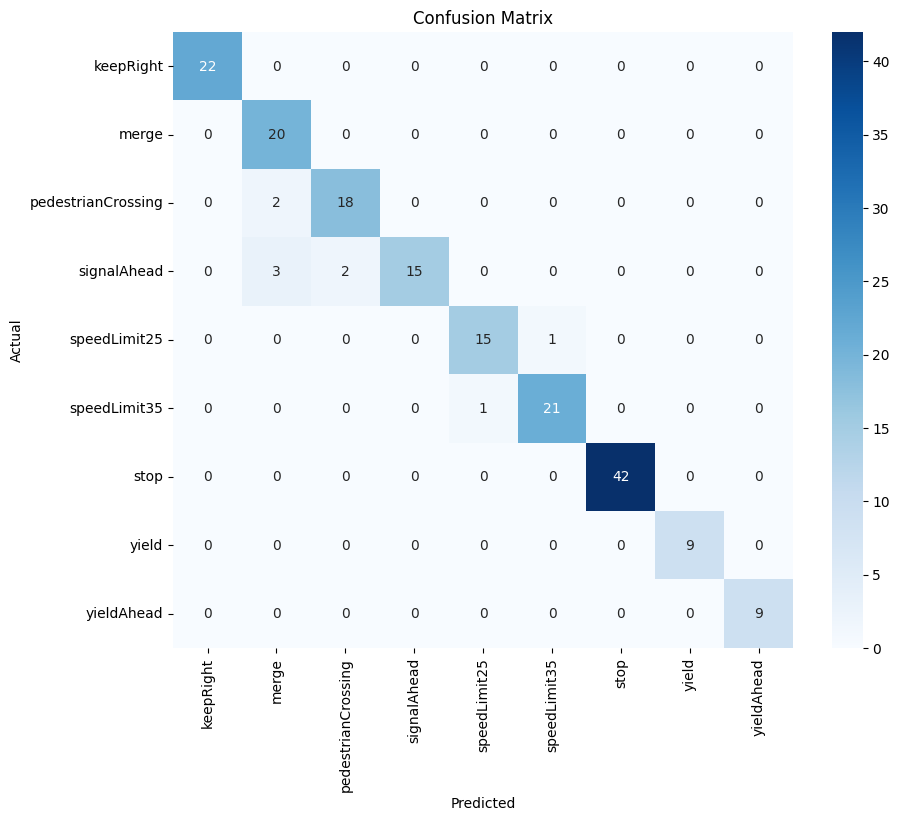


Classification Report:

                    precision    recall  f1-score   support

         keepRight       1.00      1.00      1.00        22
             merge       0.80      1.00      0.89        20
pedestrianCrossing       0.90      0.90      0.90        20
       signalAhead       1.00      0.75      0.86        20
      speedLimit25       0.94      0.94      0.94        16
      speedLimit35       0.95      0.95      0.95        22
              stop       1.00      1.00      1.00        42
             yield       1.00      1.00      1.00         9
        yieldAhead       1.00      1.00      1.00         9

          accuracy                           0.95       180
         macro avg       0.95      0.95      0.95       180
      weighted avg       0.96      0.95      0.95       180

EfficientNet


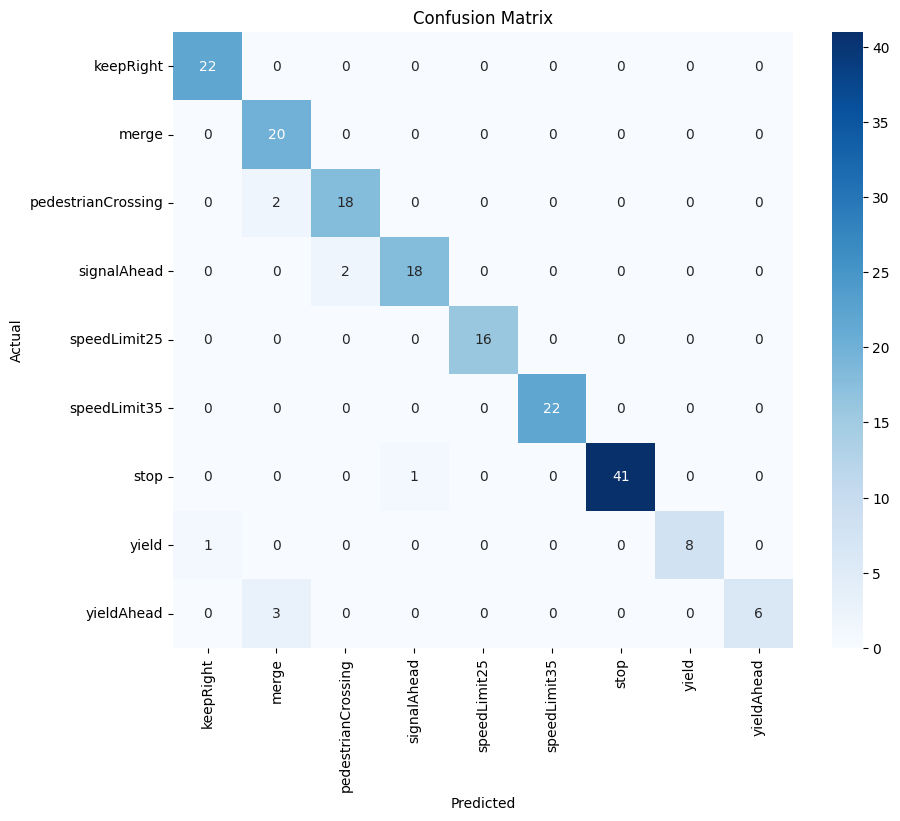


Classification Report:

                    precision    recall  f1-score   support

         keepRight       0.96      1.00      0.98        22
             merge       0.80      1.00      0.89        20
pedestrianCrossing       0.90      0.90      0.90        20
       signalAhead       0.95      0.90      0.92        20
      speedLimit25       1.00      1.00      1.00        16
      speedLimit35       1.00      1.00      1.00        22
              stop       1.00      0.98      0.99        42
             yield       1.00      0.89      0.94         9
        yieldAhead       1.00      0.67      0.80         9

          accuracy                           0.95       180
         macro avg       0.96      0.93      0.94       180
      weighted avg       0.96      0.95      0.95       180

DenseNet121


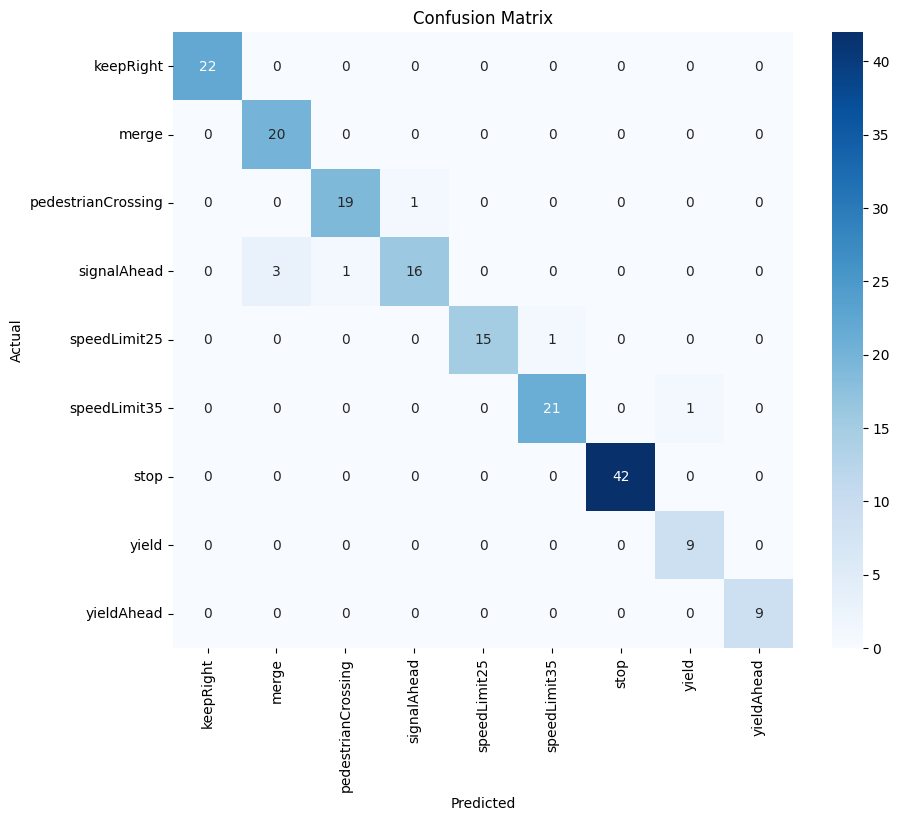


Classification Report:

                    precision    recall  f1-score   support

         keepRight       1.00      1.00      1.00        22
             merge       0.87      1.00      0.93        20
pedestrianCrossing       0.95      0.95      0.95        20
       signalAhead       0.94      0.80      0.86        20
      speedLimit25       1.00      0.94      0.97        16
      speedLimit35       0.95      0.95      0.95        22
              stop       1.00      1.00      1.00        42
             yield       0.90      1.00      0.95         9
        yieldAhead       1.00      1.00      1.00         9

          accuracy                           0.96       180
         macro avg       0.96      0.96      0.96       180
      weighted avg       0.96      0.96      0.96       180

ResNet18


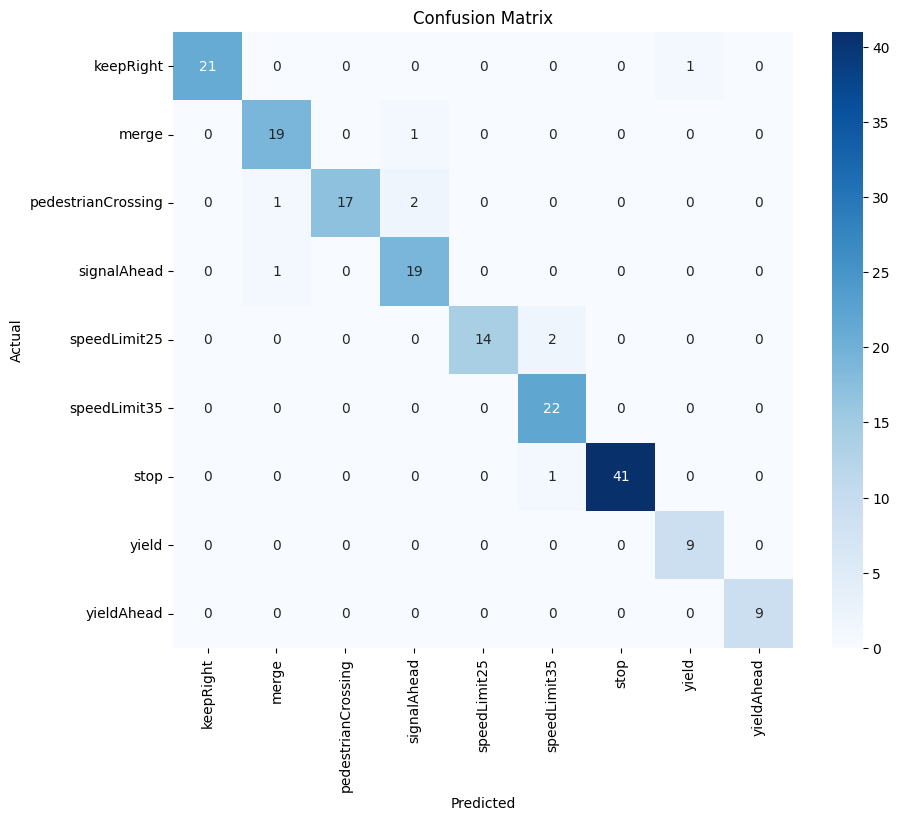


Classification Report:

                    precision    recall  f1-score   support

         keepRight       1.00      0.95      0.98        22
             merge       0.90      0.95      0.93        20
pedestrianCrossing       1.00      0.85      0.92        20
       signalAhead       0.86      0.95      0.90        20
      speedLimit25       1.00      0.88      0.93        16
      speedLimit35       0.88      1.00      0.94        22
              stop       1.00      0.98      0.99        42
             yield       0.90      1.00      0.95         9
        yieldAhead       1.00      1.00      1.00         9

          accuracy                           0.95       180
         macro avg       0.95      0.95      0.95       180
      weighted avg       0.95      0.95      0.95       180

Attention Fusion (RE + EF)


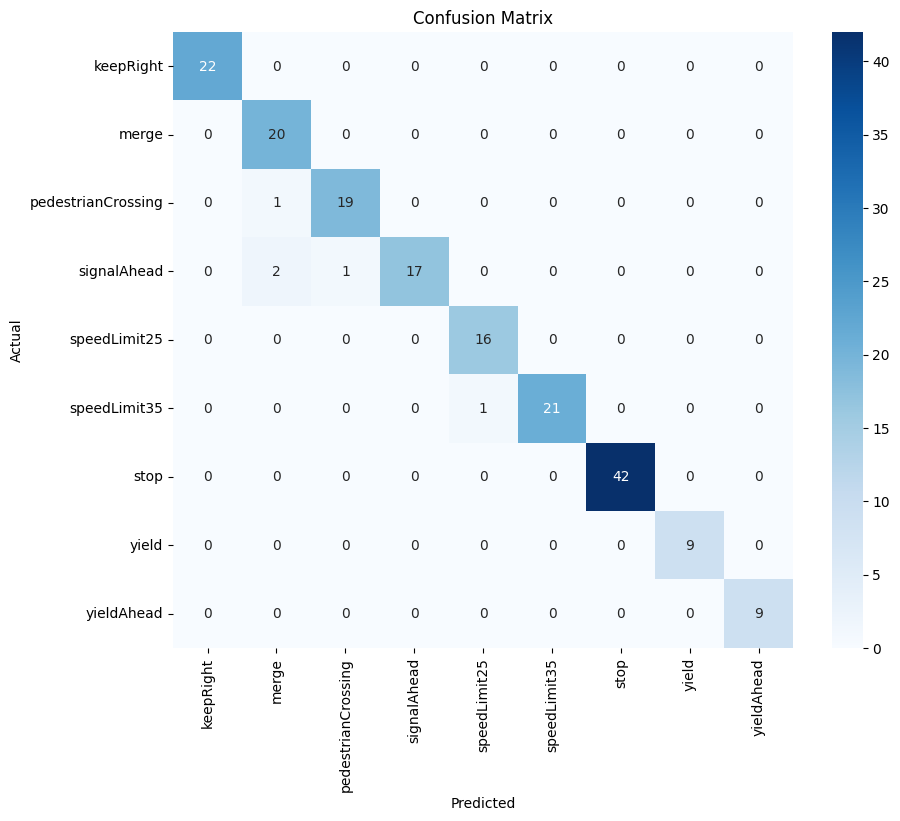


Classification Report:

                    precision    recall  f1-score   support

         keepRight       1.00      1.00      1.00        22
             merge       0.87      1.00      0.93        20
pedestrianCrossing       0.95      0.95      0.95        20
       signalAhead       1.00      0.85      0.92        20
      speedLimit25       0.94      1.00      0.97        16
      speedLimit35       1.00      0.95      0.98        22
              stop       1.00      1.00      1.00        42
             yield       1.00      1.00      1.00         9
        yieldAhead       1.00      1.00      1.00         9

          accuracy                           0.97       180
         macro avg       0.97      0.97      0.97       180
      weighted avg       0.97      0.97      0.97       180

Attention Fusion (R18 + DN)


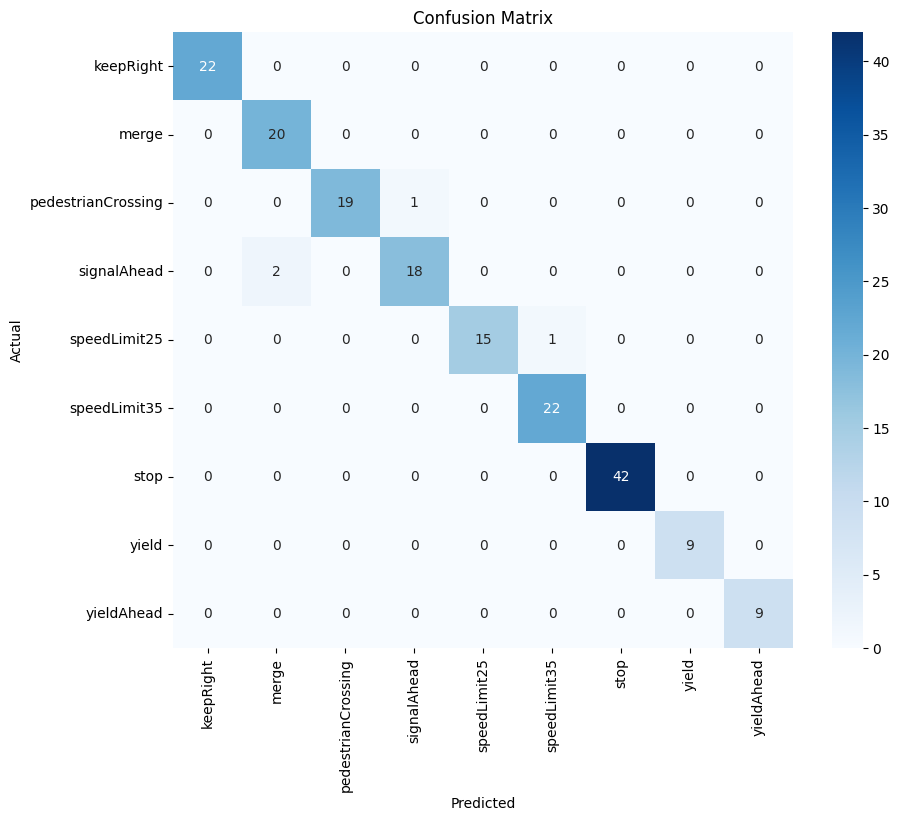


Classification Report:

                    precision    recall  f1-score   support

         keepRight       1.00      1.00      1.00        22
             merge       0.91      1.00      0.95        20
pedestrianCrossing       1.00      0.95      0.97        20
       signalAhead       0.95      0.90      0.92        20
      speedLimit25       1.00      0.94      0.97        16
      speedLimit35       0.96      1.00      0.98        22
              stop       1.00      1.00      1.00        42
             yield       1.00      1.00      1.00         9
        yieldAhead       1.00      1.00      1.00         9

          accuracy                           0.98       180
         macro avg       0.98      0.98      0.98       180
      weighted avg       0.98      0.98      0.98       180



array([[22,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 20,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 19,  1,  0,  0,  0,  0,  0],
       [ 0,  2,  0, 18,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 15,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 22,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 42,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  9,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  9]])

In [43]:
class_names = train_dataset.classes

print("ResNet50")
evaluate_full(resnet50, test_loader, class_names)

print("EfficientNet")
evaluate_full(efficientnet, test_loader, class_names)

print("DenseNet121")
evaluate_full(densenet, test_loader, class_names)

print("ResNet18")
evaluate_full(resnet, test_loader, class_names)

print("Attention Fusion (RE + EF)")
evaluate_full(model_attn1, test_loader, class_names)

print("Attention Fusion (R18 + DN)")
evaluate_full(model_attn2, test_loader, class_names)

In [44]:
def evaluate_avg_fusion(model1, model2, test_loader, class_names):

    model1.eval()
    model2.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            out1 = torch.softmax(model1(images), dim=1)
            out2 = torch.softmax(model2(images), dim=1)

            fused = (out1 + out2) / 2
            _, preds = torch.max(fused, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title("Average Fusion Confusion Matrix")
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

Avg Fusion (ResNet50 + EfficientNet)


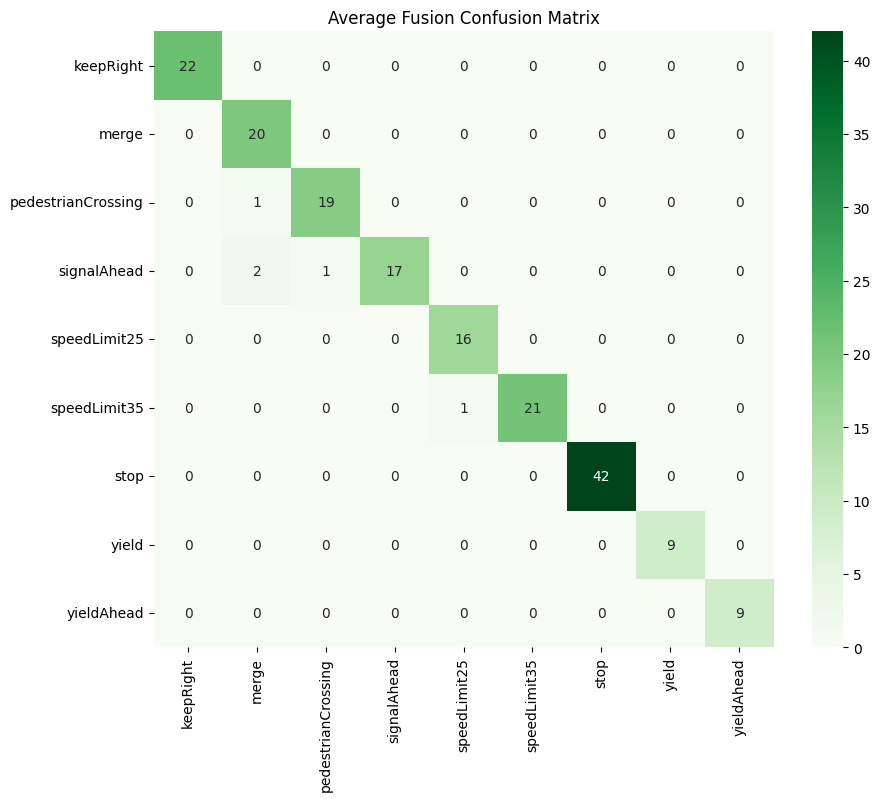


Classification Report:

                    precision    recall  f1-score   support

         keepRight       1.00      1.00      1.00        22
             merge       0.87      1.00      0.93        20
pedestrianCrossing       0.95      0.95      0.95        20
       signalAhead       1.00      0.85      0.92        20
      speedLimit25       0.94      1.00      0.97        16
      speedLimit35       1.00      0.95      0.98        22
              stop       1.00      1.00      1.00        42
             yield       1.00      1.00      1.00         9
        yieldAhead       1.00      1.00      1.00         9

          accuracy                           0.97       180
         macro avg       0.97      0.97      0.97       180
      weighted avg       0.97      0.97      0.97       180

Avg Fusion (ResNet18 + DenseNet)


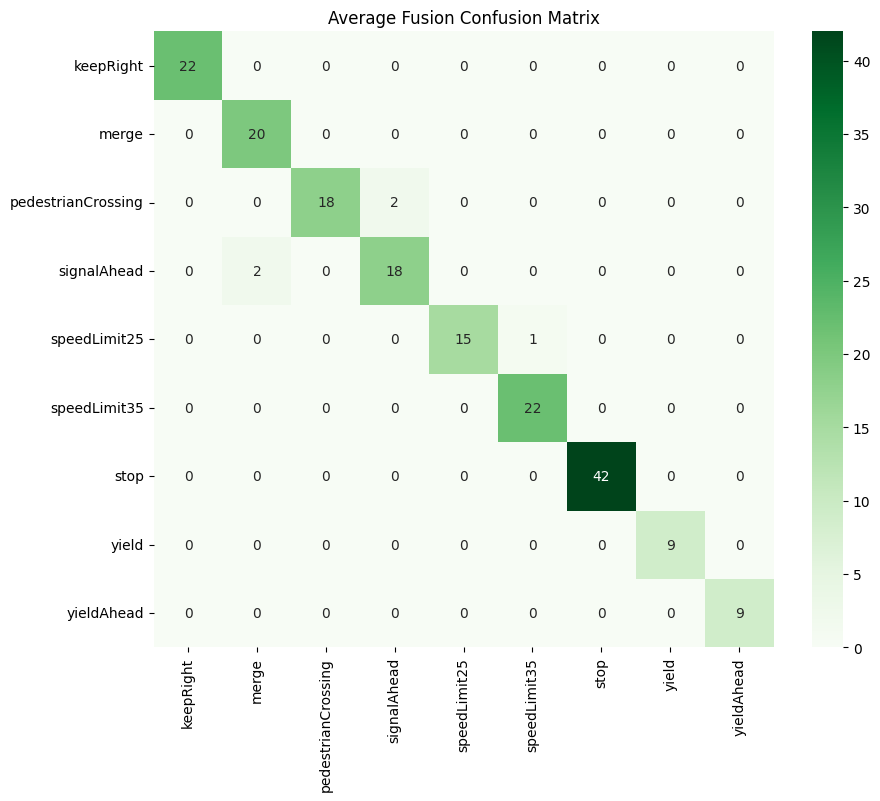


Classification Report:

                    precision    recall  f1-score   support

         keepRight       1.00      1.00      1.00        22
             merge       0.91      1.00      0.95        20
pedestrianCrossing       1.00      0.90      0.95        20
       signalAhead       0.90      0.90      0.90        20
      speedLimit25       1.00      0.94      0.97        16
      speedLimit35       0.96      1.00      0.98        22
              stop       1.00      1.00      1.00        42
             yield       1.00      1.00      1.00         9
        yieldAhead       1.00      1.00      1.00         9

          accuracy                           0.97       180
         macro avg       0.97      0.97      0.97       180
      weighted avg       0.97      0.97      0.97       180



In [45]:
print("Avg Fusion (ResNet50 + EfficientNet)")
evaluate_avg_fusion(resnet50, efficientnet, test_loader, class_names)

print("Avg Fusion (ResNet18 + DenseNet)")
evaluate_avg_fusion(resnet, densenet, test_loader, class_names)

In [46]:
import pandas as pd

data = [
    ["ResNet18", 0.9778, 0.9795, 0.9778, 0.9777],
    ["ResNet50", 0.9500, 0.9520, 0.9500, 0.9503],
    ["EfficientNet-B0", 0.9722, 0.9744, 0.9722, 0.9726],
    ["DenseNet121", 0.9556, 0.9568, 0.9556, 0.9556],
    ["MobileNet-V2", 0.9667, 0.9698, 0.9667, 0.9671],

    ["Avg Fusion (ResNet50 + EfficientNet-B0)", 0.9722, "-", "-", "-"],
    ["Avg Fusion (ResNet18 + DenseNet121)", 0.9778, "-", "-", "-"],

    ["Attention Fusion (ResNet50 + EfficientNet-B0)", 0.9833, 0.9848, 0.9833, 0.9834],
    ["Attention Fusion (ResNet18 + DenseNet121)", 0.9833, 0.9836, 0.9833, 0.9833],
]

df = pd.DataFrame(data, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

print(df.to_string(index=False))

                                        Model  Accuracy Precision  Recall F1 Score
                                     ResNet18    0.9778    0.9795  0.9778   0.9777
                                     ResNet50    0.9500     0.952    0.95   0.9503
                              EfficientNet-B0    0.9722    0.9744  0.9722   0.9726
                                  DenseNet121    0.9556    0.9568  0.9556   0.9556
                                 MobileNet-V2    0.9667    0.9698  0.9667   0.9671
      Avg Fusion (ResNet50 + EfficientNet-B0)    0.9722         -       -        -
          Avg Fusion (ResNet18 + DenseNet121)    0.9778         -       -        -
Attention Fusion (ResNet50 + EfficientNet-B0)    0.9833    0.9848  0.9833   0.9834
    Attention Fusion (ResNet18 + DenseNet121)    0.9833    0.9836  0.9833   0.9833


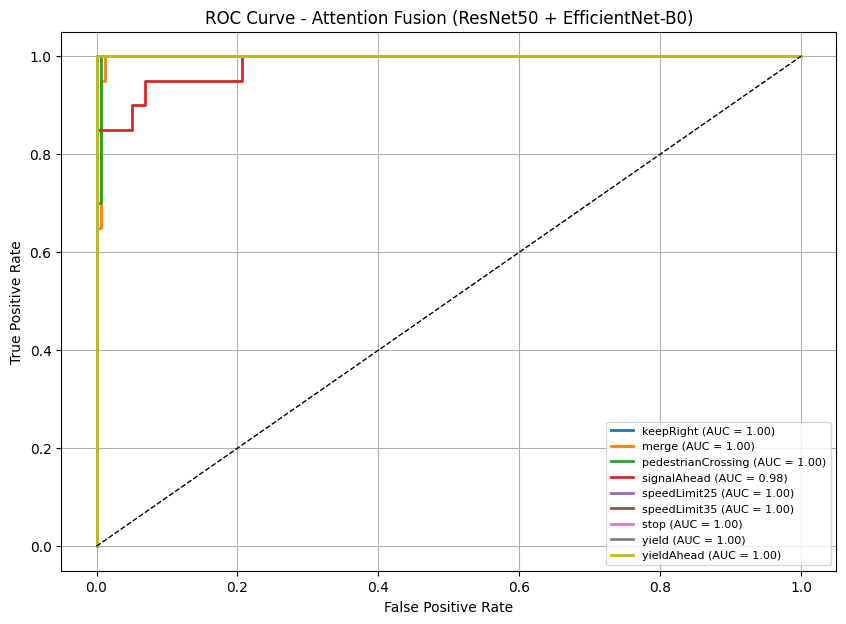

In [50]:
# ================== ROC CURVE (ALL 9 CLASSES) ==================
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_attn1.eval()

y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model_attn1(images)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)

num_classes = y_scores.shape[1]

# Binarize labels (important for multi-class ROC)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(10,7))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], linewidth=2,
             label=f'{test_loader.dataset.classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Attention Fusion (ResNet50 + EfficientNet-B0)")
plt.legend(loc="lower right", fontsize=8)
plt.grid()

plt.show()

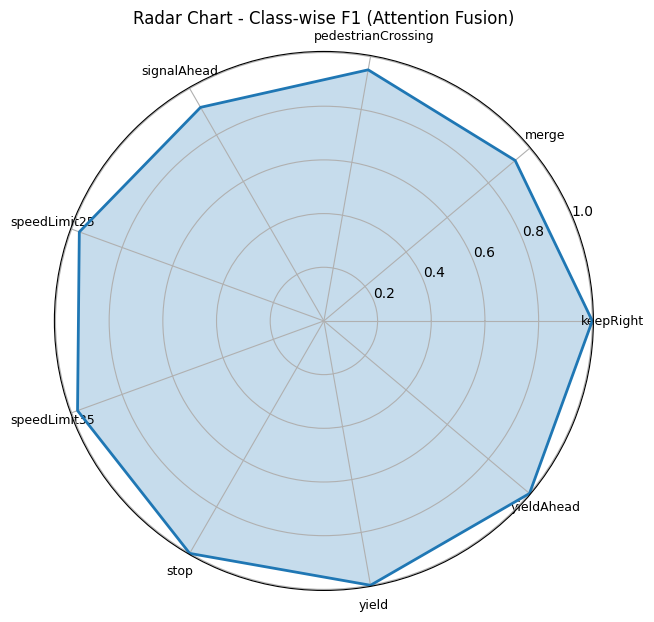

In [52]:
# ================== FIXED RADAR CHART ==================
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

model_attn1.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model_attn1(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Generate report
report = classification_report(y_true, y_pred, output_dict=True)

class_names = test_loader.dataset.classes
num_classes = len(class_names)

# ✅ FIX: use string indices '0','1',...
f1_scores = [report[str(i)]['f1-score'] for i in range(num_classes)]

# Radar setup
labels = class_names
values = f1_scores

# Close loop
values += values[:1]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Plot
plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)

plt.title("Radar Chart - Class-wise F1 (Attention Fusion)", pad=20)

plt.show()